<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/C%C3%B3pia_de_Mo%CC%81dulo_8_Aula_2_Exerci%CC%81cio_CSTR_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Técnicas de Inteligência Artificial Aplicadas às Engenharias de Processos**

28 de janeiro de 2026 | Extensão FEQ UNICAMP

Professor: Vitor Oliveira

# **Módulo 8 - Aula 1 | Controle de Processos**

# Desenvolvimento de um Controlador PID

Você foi contratado recentemente como Engenheiro de Processos da Fuzz Chemicals. Como sua primeira entrega, o seu gestor solicitou uma análise preliminar para implantação de um controle de temperatura para um CSTR exotérmico da Planta de Polimerização através da manipulação da água de resfriamento que passa pela jaqueta do reator.

No entanto, quando você foi em busca das ferramentas, descobriu que a emoresa está com problemas de renovação de licenças e você não tem acesso ao Aspen Simulator e nem ao MATLAB. Preparado pelo curso FEQ-0480, você não titubeou e propôs o uso do Python para o seu gestor, que respondeu positivamente.

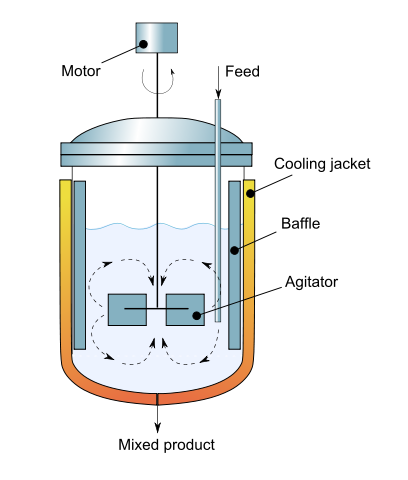

### A primeira etapa da sua análise consiste em programar o modelo matemático do CSTR.

## 1. Modelo

O modelo consiste nos balanços molar e de energia nos termos de um reator com mistura perfeita.

\begin{align*}
V\frac{dc}{dt} & = q(c_f - c )-Vk(T)c \\
\rho C_p V\frac{dT}{dt} & = wC_p(T_f - T) + (-\Delta H_R)Vk(T)c + UA(T_c-T)
\end{align*}

em que $c$ é a concentração do reagente, $T$ é a temperatura do reator, e $T_c$ é a temperatura da jaqueta. O modelo foi adaptado do exemplo 2.5 do Seborg, Edgar, Mellichamp and Doyle (SEMD), os parâmetros são dados na tabela abaixo.

A temperatura na jaqueta é manipulada através da vazão de entrada de fluido refrigerante, $q_c$, e governado pelo balanço de energia:

\begin{align*}
\rho C_p V_c\frac{dT_c}{dt} & = \rho C_p q_c(T_{cf}-T_c) + UA(T - T_c)
\end{align*}

Normalizando as equações para isolar as variações no tempo de $c$, $T$, e $T_c$ temos:

\begin{align*}
\frac{dc}{dt} & = \frac{q}{V}(c_f - c)- k(T)c\\
\frac{dT}{dt} & = \frac{q}{V}(T_i - T) + \frac{-\Delta H_R}{\rho C_p}k(T)c + \frac{UA}{\rho C_pV}(T_c - T)\\
\frac{dT_c}{dt} & = \frac{q_c}{V_c}(T_{cf}-T_c) + \frac{UA}{\rho C_pV_c}(T - T_c)
\end{align*}

Dados:

| Quantity | Symbol | Value | Units | Comments |
| :------- | :----: | :---: | :---- | :------- |
| Energia de Ativação | $E_a$ | 72,750 | J/gmol | |
| Constante pré-exponencial de Ahrrenius | $k_0$ | 7.2 x 10<sup>10</sup> | 1/min | |
| Constante dos Gases Perfeitos | $R$ | 8.314 | J/gmol/K | |
| Volume do Reator | $V$ | 100 | liters | |
| Densidade | $\rho$ | 1000 | g/liter | |
| Capacidade calorífica | $C_p$ | 0.239 | J/g/K | |
| Entalpia de Reação | $\Delta H_r$ | -50,000 | J/gmol | |
| Coeficiente de Transferência Térmica | $UA$ | 50,000 | J/min/K | |
| Vazão de alimentação | $q$ | 100 | liters/min | |
| Concentração da Entrada | $c_{A,f}$ | 1.0 | gmol/liter | |
| Temperatura da Entrada | $T_f$ | 350 | K | |
| Concentração inicial | $c_{A,0}$ | 0.5 | gmol/liter | |
| Temperatura inicial | $T_0$ | 350 | K | |
| Temperatura de entrada do fluido refrigerante | $T_{cf}$ | 300 | K | |
| Vazão de entrada do fluido refrigerante | $q_c$ | 50 | L/min | variável manipulada |
| Volume da jaqueta | $V_c$ | 20 | liters | |

## 2. Implementação da Estratégia de Controle

Implemente um controlador PID. Leve em consideração as observações a seguir:

O controle Proporcional-Integral-Derivativo (PID) é o trabalho principal da indústria de controle de processos. Em sua forma padrão, o algoritmo PID seria escrito como:

$$q_c(t) = \bar{q}_c - K_c\left[(T_{sp}-T) + \frac{1}{\tau_I}\int_0^t (T_{sp}-T)dt' + \tau_D\frac{d(T_{sp}-T)}{dt} \right]$$

Para o controle da temperatura do reator, observe que o controlador é 'de ação direta', de modo que uma excursão positiva da temperatura do reator $T$ acima do setpoint $T_{sp}$ é compensada por um aumento no fluxo do refrigerante, e vice-versa. Assim, um sinal negativo aparece antes do termo $K_c$, ao contrário da convenção usual de controle de retroalimentação negativa encontrada em livros-texto.

Leve em consideração que a implementação prática do controle PID geralmente é facilitada por várias modificações.

Faça alguns testes e aponte a melhor estratégia encontrada através das métricas de desempenho de controladores.

## 3. O Controlador Fuzzy PID Simplificado

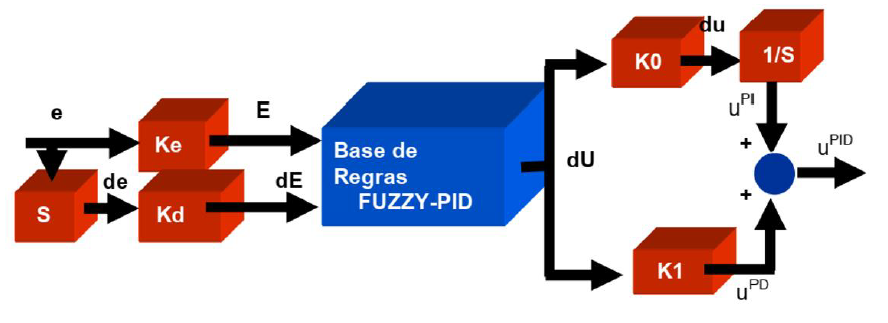

Após os testes realizados com o controlador PID convencional, você identificou que o comportamento altamente não linear do reator CSTR apresenta desafios significativos para estratégias de controle clássicas, especialmente durante regimes transientes e mudanças de setpoint.

Recordando os conceitos apresentados nas aulas de Controle Inteligente de Processos Industriais, você reconheceu que este processo é um candidato ideal para aplicação de controladores Fuzzy. Além disso, a Fuzz Chemicals conta com um diferencial estratégico: um corpo técnico de operadores experientes, cuja expertise operacional pode enriquecer significativamente o desenvolvimento das regras de controle linguísticas.

### Objetivo

Antes de propor investimentos em testes em escala piloto, seu objetivo é validar a viabilidade da abordagem através de uma prova de conceito em ambiente simulado. Você hipotetizou que a **abordagem de Li & Gatland** (Controlador Fuzzy-PID Simplificado) oferece o melhor compromisso entre simplicidade de implementação e desempenho para esta validação inicial.

Ao apresentar a proposta ao seu gestor, você obteve aprovação para prosseguir com os testes. Agora é com você: **reimplemente a simulação utilizando o Controlador Fuzzy-PID Simplificado** e demonstre, através das métricas de desempenho, se a hipótese se confirma.

### Entregável

- Implementação do controlador Fuzzy-PID segundo a abordagem de Li & Gatland
- Análise comparativa de desempenho em relação ao PID convencional (utilize as mesmas métricas da etapa anterior)
- Discussão sobre a viabilidade de avanço para testes em escala piloto